# MLP Classification

## الترتيب / Flow
1. استيراد المكتبات - Import libraries
2. قراءة البيانات - Load dataset
3. تجهيز `X` و `y` - Prepare features and target
4. تقسيم البيانات - Train/Test split
5. Feature scaling - Standardization
6. بناء MLP - Build Keras Sequential model
7. compile + fit - Train with binary cross-entropy
8. التقييم والتنبؤ - Evaluate and predict
9. Confusion matrix + scatter plot

In [1]:
# Step 1) استيراد المكتبات / Import libraries
# pip install tensorflow -q  # uncomment in Colab if needed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Step 2) قراءة البيانات / Load dataset
dataset = pd.read_csv('Social_Network_Ads.csv')
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
# Step 3) تجهيز X و y / Prepare features and target
X = dataset.iloc[:, [2, 3]].values  # Age, EstimatedSalary
y = dataset.iloc[:, 4].values       # Purchased

In [4]:
# Step 4) تقسيم البيانات / Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [5]:
# Step 5) Feature scaling / Standardization
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [6]:
# Step 6) بناء MLP / Build model
model = Sequential([
    Dense(units=64, activation='relu', input_shape=(2,)),
    Dense(units=32, activation='relu'),
    Dense(units=1, activation='sigmoid')
])
model.summary()

C:\Users\A7MED\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Step 7) compile + fit / Train model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5938 - loss: 0.6564 - val_accuracy: 0.7500 - val_loss: 0.6036
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7266 - loss: 0.6070 - val_accuracy: 0.8281 - val_loss: 0.5465
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7852 - loss: 0.5653 - val_accuracy: 0.9062 - val_loss: 0.4942
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8008 - loss: 0.5258 - val_accuracy: 0.9062 - val_loss: 0.4479
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8203 - loss: 0.4916 - val_accuracy: 0.9062 - val_loss: 0.4033
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8320 - loss: 0.4605 - val_accuracy: 0.9375 - val_loss: 0.3631
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8359 - loss: 0.4326 - val_accuracy: 0.9375 - val_loss: 0.3289
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8477 - loss: 0.4091 - val_accuracy: 0.9688 - val_loss: 0.2990
Epoch 9

In [8]:
# Step 8) التقييم والتنبؤ / Evaluate and predict
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.2%}')

y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

Test loss: 0.1727
Test accuracy: 95.00%


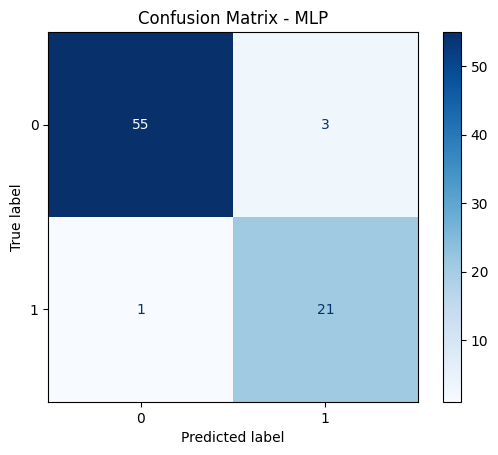

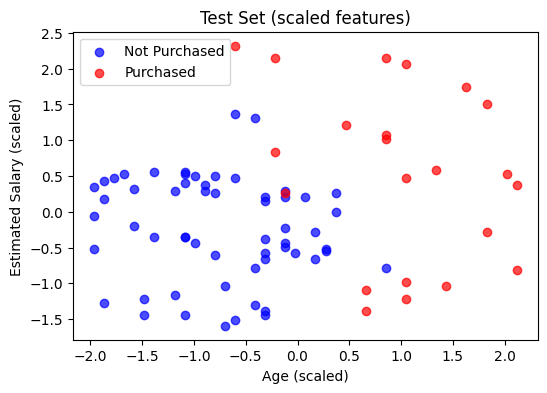

In [9]:
# Step 9) Confusion matrix + scatter / Evaluation plots
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Confusion Matrix - MLP')
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c='blue', label='Not Purchased', alpha=0.7)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c='red', label='Purchased', alpha=0.7)
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('Test Set (scaled features)')
plt.legend()
plt.show()